# Diamantpriser: linjär regression vs. beslutsträd

Målet är att förutsäga `price` utifrån diamantens egenskaper och se vilken av de två
modellerna som gissar minst fel.

## Import och data

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("../dataset/diamonds.csv")

print("Storlek:", df.shape)
print("Kolumner:", list(df.columns))
print("Saknade värden:", df.isna().sum().sum())
display(df.head())

Storlek: (53940, 11)
Kolumner: ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
Saknade värden: 0


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Förbereda data

In [2]:
df = df.drop(columns=["Unnamed: 0"])  # bara radnummer från CSV-filen, ingen information

X = pd.get_dummies(df.drop(columns=["price"]))  # allt utom price = features, text -> 0/1-kolumner
y = df["price"]                                 # price = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Träning:", X_train.shape, " Test:", X_test.shape)

Träning: (43152, 26)  Test: (10788, 26)


## Träna och jämföra

MAE = genomsnittligt fel i kronor. RMSE straffar stora missar hårdare.
Lägre är bättre för båda.

In [ ]:
lin = LinearRegression().fit(X_train, y_train)
tree = DecisionTreeRegressor(random_state=1337).fit(X_train, y_train)

for namn, modell in [("Linjär regression", lin), ("Beslutsträd", tree)]:
    pred = modell.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    print(f"{namn:20} MAE: {mae:7.0f}   RMSE: {rmse:7.0f}")

# Referens: hur bra är "gissa medelpriset varje gång"?
baseline = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"{'Gissa medelvärdet':20} MAE: {baseline:7.0f}")

Linjär regression    MAE:     737   RMSE:    1135
Beslutsträd          MAE:     362   RMSE:     747
Gissa medelvärdet    MAE:    3021


### Vad tittar trädet på?

In [4]:
vikter = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(vikter.head(5).round(3).to_string())

carat          0.634
y              0.253
clarity_SI2    0.019
clarity_I1     0.015
clarity_SI1    0.014


### Varför en rak linje inte räcker

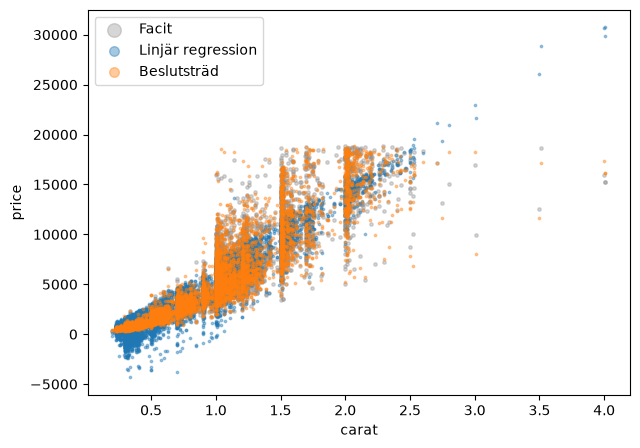

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_test["carat"], y_test, s=6, alpha=0.35, color="0.55", label="Facit")
ax.scatter(X_test["carat"], lin.predict(X_test), s=3, alpha=0.4, label="Linjär regression")
ax.scatter(X_test["carat"], tree.predict(X_test), s=3, alpha=0.4, label="Beslutsträd")
ax.set_xlabel("carat")
ax.set_ylabel("price")
ax.legend(markerscale=4)
plt.show()


### Några enskilda gissningar

In [ ]:
jmf = pd.DataFrame({"facit": y_test, "gissning": tree.predict(X_test).round(0)})
jmf["fel"] = (jmf["gissning"] - jmf["facit"]).round(0)

print("Tio slumpvisa testdiamanter:")
print(jmf.sample(10, random_state=1337).to_string())

print("\nStörst miss:")
print(jmf.reindex(jmf["fel"].abs().sort_values(ascending=False).index).head(3).to_string())

Tio slumpvisa testdiamanter:
       facit  gissning     fel
52383   2507    2404.0  -103.0
44166   1565    1752.0   187.0
33620    463     518.0    55.0
16227   6488    6860.0   372.0
37037    967    1033.0    66.0
26776  16618   17009.0   391.0
22808  10833   12388.0  1555.0
42638   1332    1279.0   -53.0
41940    504     647.0   143.0
36425    942     942.0     0.0

Störst miss:
       facit  gissning     fel
27113  17267   10162.0 -7105.0
21935  10011    3003.0 -7008.0
27673  18691   12014.0 -6677.0


## Overfitting-koll

Ett obegränsat träd får växa tills varje löv är en enda diamant — då memorerar det
träningsdatan. Jämför felet på data modellen sett (träning) med data den aldrig sett (test).

In [ ]:
d8 = DecisionTreeRegressor(max_depth=8, random_state=1337).fit(X_train, y_train)

for namn, m in [("Linjär regression", lin), ("Träd (obegränsat)", tree), ("Träd (max_depth=8)", d8)]:
    tr = mean_absolute_error(y_train, m.predict(X_train))
    te = mean_absolute_error(y_test, m.predict(X_test))
    print(f"{namn:20} MAE träning: {tr:6.0f}   MAE test: {te:6.0f}")

Linjär regression    MAE träning:    742   MAE test:    737
Träd (obegränsat)    MAE träning:      0   MAE test:    362
Träd (max_depth=8)   MAE träning:    472   MAE test:    476


## Slutsats

**Beslutsträdet vann.** MAE 362 mot linjär regressions 737 — och mot 3021 för att bara gissa medelpriset. Båda modellerna lärde sig alltså något verkligt, trädet ungefär dubbelt så bra.

**Varför trädet är bättre:** priset stiger inte linjärt med carat, det stiger allt brantare. Linjär regression kan bara dra en rak linje genom det och missar därför systematiskt i båda ändarna — den gissar till och med negativa priser för de minsta diamanterna. Trädet delar upp datan i intervall och kan följa kurvan.

**Carat är nästan hela historien.** carat + y (bredden) står för 89 % av trädets beslut. Slipning, färg och klarhet spelar förvånansvärt liten roll i jämförelse — storlek styr priset.

**Trädet är överanpassat, men det gör inget här.** MAE 0 på träningsdatan betyder att det memorerat varje diamant. Ändå presterar det bäst på testdatan, och `max_depth=8` gjorde det sämre (476). Med 43 000 träningsrader finns det helt enkelt tillräckligt mycket data för att memorering ska generalisera hyfsat.

**Var det går fel:** de största missarna är dyra diamanter (17 000–18 000 kr) som gissas till ungefär hälften. Sådana är sällsynta i datan, så trädet har få liknande exempel att gå på och drar ner mot vanligare priser.